<a href="https://colab.research.google.com/github/miaflynn/CYPLAN255-Final-Project/blob/main/03a_visualizations_censustract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sub Question 1: Which neighborhoods (and census tracts) experienced the highest rates of business closures during 2020-2021, and which show the most new openings (recovery) from 2022 to 2025?**

## Set Up

In [90]:
!pip install contextily

In [91]:
import pandas as pd
import geopandas as gpd
import numpy as np

#added more that we use in lab
import os
%matplotlib inline
import matplotlib.pyplot as plt
from shapely.geometry import LineString


In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
!ls /content/drive
!ls /content/drive/Shareddrives

MyDrive  Shareddrives


In [94]:
import pandas as pd

gdf = gpd.read_file("/content/drive/MyDrive/Courses/Spring 2026/Urban Informatics/C255_final_project/cleaned/open_close_after_2016.geojson")

In [95]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 147785 entries, 0 to 147784
Data columns (total 19 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   uniqueid                           147785 non-null  object        
 1   business_account_number            147785 non-null  int32         
 2   location_id                        147785 non-null  object        
 3   ownership_name                     147785 non-null  object        
 4   dba_name                           147633 non-null  object        
 5   business_start_date                147785 non-null  datetime64[ms]
 6   business_end_date                  75020 non-null   datetime64[ms]
 7   location_start_date                147785 non-null  datetime64[ms]
 8   location_end_date                  107000 non-null  datetime64[ms]
 9   naics_code                         145831 non-null  object        
 10  naics_code_d

In [96]:
# # adding another plot and importing a shpfile of SF so we can see where the points are in SF

# import matplotlib.pyplot as plt

# # Importing SF geometry
# # URL for 2025 TIGER/Line Place boundaries - info here on
# ## how to use: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
url = "https://www2.census.gov/geo/tiger/TIGER2025/PLACE/tl_2025_06_place.zip"

places = gpd.read_file(url)

# Filtered to SF
sf_poly = places[
    (places["NAME"] == "San Francisco") &
    (places["STATEFP"] == "06")   # 06 = California
]


# project to same as our gdf
sf_poly = sf_poly.to_crs(epsg=4326)

## Plotting Closings vs. Openings over time for all businesses

In [97]:
import plotly.express as px

# counting number of opening and closings - Abigail
counts = gdf.groupby(["year", "status"]).size().reset_index(name="count")
counts = counts[counts["year"] <= 2025]

# Making graph of this
fig = px.line(
    counts,
    x="year",
    y="count",
    color="status",
    markers=True
)

# Adding labels
fig.update_layout(
    title="San Francisco Business Openings vs Closings (2016–2025)",
    xaxis_title="Year",
    yaxis_title="Number of Businesses",
    legend_title="Status"
)

#adding code to show each year on x-axis
fig.update_xaxes(dtick=1)
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white"
)

#making background white and removing vert lines
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_xaxes(
    showgrid=False,
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray"
)

fig.show()


## **Tract Level Analysis**

In [98]:
#I added a shp file with census tracts to our folder

tracts_gdf = gpd.read_file(
    "/content/drive/MyDrive/Courses/Spring 2026/Urban Informatics/C255_final_project/cb_2020_06_tract_500k"
)

In [99]:
#checking to make sure all good

tracts_gdf.columns

# simplifying
tracts_gdf = tracts_gdf[["NAME", "NAMELSAD", "STATE_NAME","GEOID", "geometry"]]


In [100]:
# was getting error with "index_right" - removing from both dfs
tracts_gdf = tracts_gdf.drop(columns=["index_right", ], errors="ignore")
gdf = gdf.drop(columns=["index_right"], errors="ignore")

In [101]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 147785 entries, 0 to 147784
Data columns (total 19 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   uniqueid                           147785 non-null  object        
 1   business_account_number            147785 non-null  int32         
 2   location_id                        147785 non-null  object        
 3   ownership_name                     147785 non-null  object        
 4   dba_name                           147633 non-null  object        
 5   business_start_date                147785 non-null  datetime64[ms]
 6   business_end_date                  75020 non-null   datetime64[ms]
 7   location_start_date                147785 non-null  datetime64[ms]
 8   location_end_date                  107000 non-null  datetime64[ms]
 9   naics_code                         145831 non-null  object        
 10  naics_code_d

In [102]:
# Joining the gdf and tract gdf so we can summarize within tracts

gdf = gdf.set_crs(epsg=4326)
tracts_gdf = tracts_gdf.to_crs(epsg=4326)

# joining within
business_tracts_gdf = gpd.sjoin(gdf, tracts_gdf, how="left", predicate="within")

In [103]:
business_tracts_gdf = business_tracts_gdf[(business_tracts_gdf["year"] >= 2016) & (business_tracts_gdf["year"] <= 2025)]

In [104]:
# I'm counting the number of businesses per tract per year, separated by closing and openings status
tract_year = (
    business_tracts_gdf
    .groupby(["GEOID", "year", "status"])
    .size()
    .reset_index(name="count")
    .pivot(index=["GEOID", "year"], columns="status", values="count")
    .fillna(0)
    .reset_index()
)

In [105]:
tracts_plot = tracts_gdf[["GEOID", "geometry"]].merge(
    tract_year,
    on="GEOID",
    how="left"
).fillna(0)

In [106]:
tracts_plot.info()
tracts_plot = gpd.clip(tracts_plot, sf_poly)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11267 entries, 0 to 11266
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   GEOID     11267 non-null  object  
 1   geometry  11267 non-null  geometry
 2   year      11267 non-null  float64 
 3   closed    11267 non-null  float64 
 4   opened    11267 non-null  float64 
dtypes: float64(3), geometry(1), object(1)
memory usage: 440.2+ KB


In [107]:
tracts_plot["year"] = tracts_plot["year"].astype(int)
tracts_plot = tracts_plot.sort_values(["GEOID", "year"])

In [108]:
print(tracts_plot.columns)

Index(['GEOID', 'geometry', 'year', 'closed', 'opened'], dtype='object')


In [109]:
# opened = tracts_plot[tracts_plot["status"] == "opened"]
# closed = tracts_plot[tracts_plot["status"] == "closed"]

In [110]:
# This is the code I used to make some interactive visualizations, but the file size was preventing me from uploading to Github. I commented this out for now so I could upload.

# fig_closed = px.choropleth_mapbox(
#     closed,
#     geojson=closed.set_index("GEOID").__geo_interface__,
#     locations="GEOID",
#     color="count",
#     hover_name="GEOID",
#     animation_frame="year",
#     mapbox_style="carto-positron",
#     zoom=10,
#     center={"lat": 37.7749, "lon": -122.4194},  # centering on SF becuase it wasn't when I tested
#     color_continuous_scale="Reds",
#     height=600
# )

# fig_closed.update_layout(title="Business Closings by Census Tract (2016–2025)")
# fig_closed.show()

In [111]:
# fig_opened = px.choropleth_mapbox(
#     opened,
#     geojson=closed.set_index("GEOID").__geo_interface__,
#     locations="GEOID",
#     color="count",
#     hover_name="GEOID",
#     animation_frame="year",
#     mapbox_style="carto-positron",
#     zoom=10,
#     center={"lat": 37.7749, "lon": -122.4194},  # centering on SF becuase it wasn't when I tested
#     color_continuous_scale="Blues",
#     height=600
# )

# fig_opened.update_layout(title="Business Openings by Census Tract (2016–2025)")
# fig_opened.show()

Census Tract Analysis - Baselining

In [112]:
# Reformatting so each row is a unique count per tract, year, and status (so we don't have closings and openings for business in one row)
business_tracts_separated = (
    business_tracts_gdf
    .groupby(["GEOID", "year", "status"])
    .size()
    .reset_index(name="count")
)

In [113]:
# Baselining by 2016

baseline = business_tracts_separated[business_tracts_separated["year"] == 2016][["GEOID", "status", "count"]].rename(columns={"count": "baseline"}) # makes new df and filtering for only 2016 so we can use as baseline
business_tracts_separated = business_tracts_separated.merge(baseline, on=["GEOID", "status"], how="left") # joining this new baseline df to business tracts df so we can calculate change
business_tracts_separated["change_from_2016"] = business_tracts_separated["count"] - business_tracts_separated["baseline"] # subtracts change from baseline


In [114]:
tracts_plot = tracts_gdf[["GEOID", "geometry"]].merge(
    business_tracts_separated,
    on="GEOID",
    how="left"
).fillna(0)

In [115]:
opened = tracts_plot[tracts_plot["status"] == "opened"]
closed = tracts_plot[tracts_plot["status"] == "closed"]

In [116]:
# sanity check on changes

opened["change_from_2016"].describe()

# most tracts didn't have major changes (average of 3 fewer openings compared to 2016)
# but some tracts had a major change (both pos and neg compared to 2016)- these extremes will skew our viz

,change_from_2016
count,2392.000000
mean,-3.406355
std,30.107593
min,-504.000000
25%,-10.000000
50%,-1.000000
75%,5.000000
max,426.000000


In [117]:
closed["change_from_2016"].describe()

,change_from_2016
count,2379.000000
mean,14.738546
std,26.107072
min,-11.000000
25%,4.000000
50%,10.000000
75%,18.000000
max,510.000000


In [118]:
# fig = px.choropleth_mapbox(
#     opened,
#     geojson=tracts_plot.set_index("GEOID").__geo_interface__,
#     locations="GEOID",
#     color="change_from_2016",
#     hover_name="GEOID",
#     animation_frame="year",
#     mapbox_style="carto-positron",
#     zoom=11,
#     center={"lat": 37.7749, "lon": -122.4194},
#     color_continuous_scale="Blues",
#     range_color=[-20, 20], # adding this so that the legend scale doesn't change each year - need to make decision around this bc min and max will not show most changes
#     height=600,
# )

# fig.update_layout(title="SF Business Openings Change from 2016 by Census Tract")
# fig.show()

In [119]:
# fig.write_html("sf_business_map.html")

In [120]:
# from google.colab import files
# files.download("sf_business_map.html")

In [121]:
# fig = px.choropleth_mapbox(
#     closed,
#     geojson=tracts_plot.set_index("GEOID").__geo_interface__,
#     locations="GEOID",
#     color="change_from_2016",
#     hover_name="GEOID",
#     animation_frame="year",
#     mapbox_style="carto-positron",
#     zoom=11,
#     center={"lat": 37.7749, "lon": -122.4194},
#     color_continuous_scale="Reds",
#     range_color=[-10,20],
#     height=600,
# )

# fig.update_layout(title="SF Business Closings Change from 2016 by Census Tract")
# fig.show()

## Neighborhood Level Analysis

In [122]:
# Adding SF neighborhood geometry

nbhd_gdf = gpd.read_file(
    "/content/drive/MyDrive/Courses/Spring 2026/Urban Informatics/C255_final_project/SF_neighborhoods_geom"
)

In [123]:
nbhd_gdf.drop(columns=["link"], inplace=True)

In [124]:
nbhd_gdf.columns

Index(['name', 'geometry'], dtype='object')

In [126]:
# Joining the gdf and nbhd gdf so we can summarize within nbhds

gdf = gdf.set_crs(epsg=4326)
nbhd_gdf = nbhd_gdf.to_crs(epsg=4326)

# joining within
business_neighborhood_gdf = gpd.sjoin(gdf, nbhd_gdf, how="left", predicate="within")

In [127]:
business_neighborhood_gdf.columns

Index(['uniqueid', 'business_account_number', 'location_id', 'ownership_name',
       'dba_name', 'business_start_date', 'business_end_date',
       'location_start_date', 'location_end_date', 'naics_code',
       'naics_code_description', 'lic_code', 'lic_code_description',
       'business_corridor', 'neighborhoods_analysis_boundaries',
       'administratively_closed_bool', 'year', 'status', 'geometry',
       'index_right', 'name'],
      dtype='object')

Which neighborhoods (and census tracts) experienced the highest rates of business closures during 2020-2021, and which show the most new openings (recovery) from 2022 to 2025?

In [188]:
gdf = business_neighborhood_gdf.copy()

# filtering for 2019 to 2025
gdf = gdf[gdf['year'].between(2019, 2025)]

# openings
openings = (
    gdf[gdf['status'] == 'opened']
    .groupby(['name', 'year'])
    .size()
    .unstack(fill_value=0)
)

# closings
closings = (
    gdf[gdf['status'] == 'closed']
    .groupby(['name', 'year'])
    .size()
    .unstack(fill_value=0)
)

# making sure all years are there
all_years = range(2019, 2026)
openings = openings.reindex(columns=all_years, fill_value=0)
closings = closings.reindex(columns=all_years, fill_value=0)

# renaming columns to be open_year
openings.columns = [f"open_{y}" for y in openings.columns]
closings.columns = [f"close_{y}" for y in closings.columns]

# combining openings and closings to get a table to compare across neighborhoods
neighborhood_table = openings.join(closings, how='outer').fillna(0).astype(int)

neighborhood_table

,open_2019,open_2020,open_2021,open_2022,open_2023,open_2024,open_2025,close_2019,close_2020,close_2021,close_2022,close_2023,close_2024,close_2025
name,,,,,,,,,,,,,,
Alamo Square,29,22,22,19,22,21,5,12,21,20,12,14,17,12
Anza Vista,16,18,13,6,16,6,4,17,18,6,4,7,11,15
Apparel City,40,82,36,24,38,18,23,19,24,42,17,16,30,20
Aquatic Park / Ft. Mason,55,27,31,37,38,14,14,35,23,18,20,19,18,14
Ashbury Heights,29,23,19,9,20,12,9,17,17,23,8,11,15,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Portal,70,69,66,47,54,54,14,32,45,46,33,41,59,35
Western Addition,123,78,63,34,50,58,16,54,59,72,49,43,52,41
Westwood Highlands,0,4,2,3,0,4,2,0,1,5,2,1,2,7


Need to baseline by number of businesses in each neighborhood

In [189]:
gdf = business_neighborhood_gdf.copy()

# baseline by total # of businesses
baseline = gdf.groupby('name')['uniqueid'].nunique()

# closures during COVID (2020–2021)
closures = gdf[
    (gdf['year'].between(2020, 2021)) &
    (gdf['status'] == 'closed')
].groupby('name').size()

# openings during recovery (2022–2025)
openings = gdf[
    (gdf['year'].between(2022, 2025)) &
    (gdf['status'] == 'opened')
].groupby('name').size()

# combine
rate_table = pd.DataFrame({
    'baseline': baseline,
    'closures_2020_21': closures,
    'openings_2022_25': openings
}).fillna(0)

# adding rates
rate_table['closure_rate'] = rate_table['closures_2020_21'] / rate_table['baseline']
rate_table['recovery_rate'] = rate_table['openings_2022_25'] / rate_table['baseline']

rate_table

,baseline,closures_2020_21,openings_2022_25,closure_rate,recovery_rate
name,,,,,
Alamo Square,259,41.0,67,0.158301,0.258687
Anza Vista,165,24.0,32,0.145455,0.193939
Apparel City,389,66.0,103,0.169666,0.264781
Aquatic Park / Ft. Mason,341,41.0,103,0.120235,0.302053
Ashbury Heights,236,40.0,50,0.169492,0.211864
...,...,...,...,...,...
West Portal,669,91.0,169,0.136024,0.252616
Western Addition,770,131.0,158,0.170130,0.205195
Westwood Highlands,37,6.0,9,0.162162,0.243243


In [157]:
import ipywidgets as widgets

years = list(range(2019, 2026))

def plot_neighborhood(neighborhood_name):

    # baselining data from nbhd table
    row = neighborhood_table.loc[neighborhood_name]
    base = rate_table.loc[neighborhood_name, 'baseline']

    openings = row[[f"open_{y}" for y in years]] / base
    closings = row[[f"close_{y}" for y in years]] / base

    # make closings negative
    closings = -closings

    # plotting bar graph
    plt.figure(figsize=(8,4))

    plt.bar(years, openings, label='Openings (rate)', color='blue')
    plt.bar(years, closings, label='Closings (rate)', color='orange')

    plt.xlabel('Year')
    plt.ylabel('Rate (normalized)')
    plt.title(f'Business Open/Close Rates: {neighborhood_name}')

    plt.xticks(years)
    plt.ylim(-0.2, 0.2)

    plt.legend()
    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_neighborhood,
    neighborhood_name=widgets.Dropdown(options=neighborhood_table.index)
)

interactive(children=(Dropdown(description='neighborhood_name', options=('Alamo Square', 'Anza Vista', 'Appare…

<function __main__.plot_neighborhood(neighborhood_name)>

Now plotting businesses closure rate by neighborhood

In [191]:
# Filtering to nbhds with at least 50 businesses
rate_table_filtered = rate_table[rate_table['baseline'] >= 50]

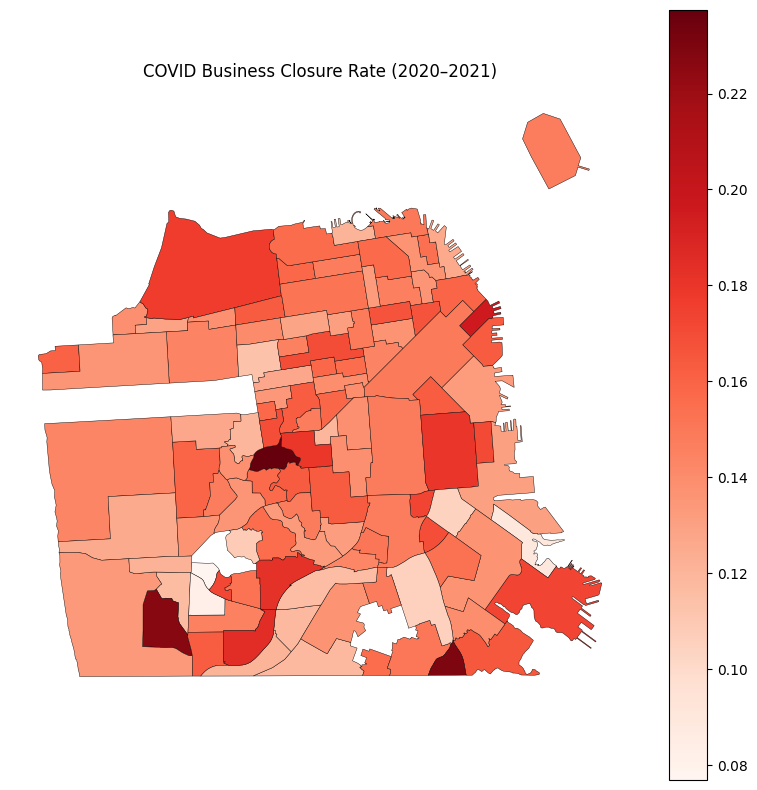

In [174]:
import matplotlib.pyplot as plt

map_gdf = nbhd_gdf.copy()

# merging closure rates
map_gdf = map_gdf.merge(
    rate_table_filtered[['closure_rate']],
    left_on='name',
    right_index=True,
    how='left'
)

# plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

map_gdf.plot(
    column='closure_rate',
    cmap='Reds',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)

ax.set_title("COVID Business Closure Rate (2020–2021)")
ax.axis('off')

plt.show()

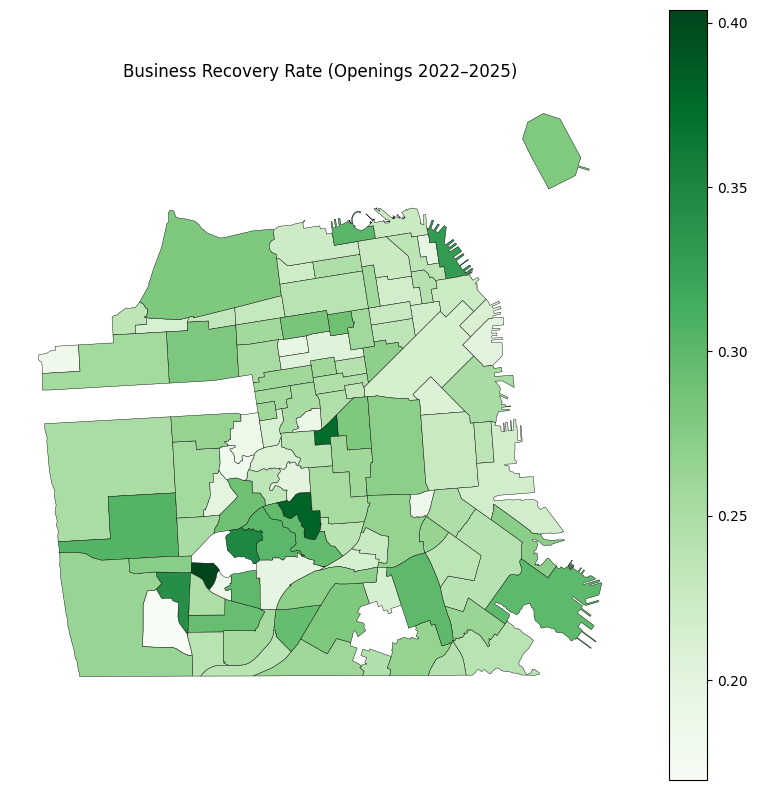

In [175]:
map_gdf = nbhd_gdf.copy()

# merge opening (recovery) rates
map_gdf = map_gdf.merge(
    rate_table_filtered[['recovery_rate']],
    left_on='name',
    right_index=True,
    how='left'
)

# plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

map_gdf.plot(
    column='recovery_rate',
    cmap='Greens',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    ax=ax
)

ax.set_title("Business Recovery Rate (Openings 2022–2025)")
ax.axis('off')

plt.show()

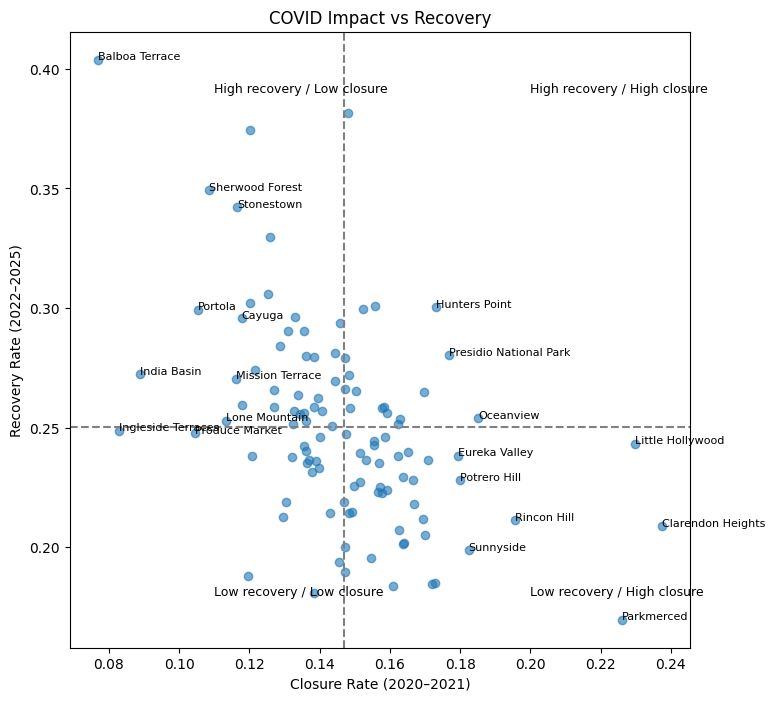

In [186]:
import matplotlib.pyplot as plt

x = rate_table_filtered['closure_rate']
y = rate_table_filtered['recovery_rate']

plt.figure(figsize=(8,8))

plt.scatter(x, y, alpha=0.6)

# labeling only the largest and smallest rates in each quadrant bc its too many points
plt.text(0.11, 0.39, "High recovery / Low closure", fontsize=9)
plt.text(0.20, 0.39, "High recovery / High closure", fontsize=9)
plt.text(0.11, 0.18, "Low recovery / Low closure", fontsize=9)
plt.text(0.20, 0.18, "Low recovery / High closure", fontsize=9)

for name in list(top) + list(bottom):
    plt.text(x.loc[name], y.loc[name], name, fontsize=8)

plt.xlabel('Closure Rate (2020–2021)')
plt.ylabel('Recovery Rate (2022–2025)')
plt.title('COVID Impact vs Recovery')

plt.axvline(x.mean(), linestyle='--', color='gray')
plt.axhline(y.mean(), linestyle='--', color='gray')

plt.show()
